# Assignment 4 — Full Deep Learning Pipeline

This notebook runs the **full experiment** for Assignment 4 using the IMDB dataset.

It does all of the following:
- loads the IMDB dataset
- limits reviews to **150 words**
- uses the **top 10,000 words**
- uses **10,000 samples for validation**
- compares:
  - **Pretrained GloVe Embedding**
  - **Trainable Embedding**
- runs multiple training sample sizes
- saves:
  - `results.csv`
  - `results_plot.png`
  - `auto_summary.md`



In [1]:
# Install / imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Configuration


In [2]:
MAX_WORDS = 10000
MAXLEN = 150
EMBEDDING_DIM = 100
VALIDATION_SIZE = 10000
BATCH_SIZE = 32
EPOCHS = 20
TRAINING_SIZES = [100, 200, 500, 1000, 2000, 5000]
GLOVE_URL = "http://nlp.stanford.edu/data/glove.6B.zip"
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Load IMDB dataset

The dataset is loaded using Keras, then padded/truncated to 150 words.

In [3]:
# Load IMDB data
(x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=MAX_WORDS)

print("Original training samples:", len(x_train_full))
print("Original test samples:", len(x_test))

# Pad / truncate sequences
x_train_full = sequence.pad_sequences(x_train_full, maxlen=MAXLEN)
x_test = sequence.pad_sequences(x_test, maxlen=MAXLEN)

print("Training shape after padding:", x_train_full.shape)
print("Test shape after padding:", x_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Original training samples: 25000
Original test samples: 25000
Training shape after padding: (25000, 150)
Test shape after padding: (25000, 150)


## Create validation set

Per the assignment, validation uses **10,000 samples**.

In [4]:
# Split validation set from the start of the training data
x_val = x_train_full[:VALIDATION_SIZE]
partial_x_train = x_train_full[VALIDATION_SIZE:]

y_val = y_train_full[:VALIDATION_SIZE]
partial_y_train = y_train_full[VALIDATION_SIZE:]

print("Validation shape:", x_val.shape)
print("Remaining training shape:", partial_x_train.shape)

Validation shape: (10000, 150)
Remaining training shape: (15000, 150)


## Prepare the word index and reverse index

In [5]:
word_index = imdb.get_word_index()
print("Word index size:", len(word_index))

# Keras reserves indices
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print("Example decoded review snippet:")
print(decode_review(x_train_full[0][:50]))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
Word index size: 88584
Example decoded review snippet:
it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you


## Download and read GloVe embeddings

This downloads `glove.6B.100d.txt`, then builds the embedding matrix.

In [6]:
import zipfile
import urllib.request

glove_zip_path = "glove.6B.zip"
glove_txt_path = "glove.6B.100d.txt"

if not os.path.exists(glove_txt_path):
    if not os.path.exists(glove_zip_path):
        print("Downloading GloVe...")
        urllib.request.urlretrieve(GLOVE_URL, glove_zip_path)
    print("Extracting GloVe...")
    with zipfile.ZipFile(glove_zip_path, "r") as zip_ref:
        zip_ref.extractall(".")

print("GloVe file ready:", os.path.exists(glove_txt_path))

Extracting GloVe...
GloVe file ready: True


In [7]:
# Load GloVe embeddings into a dictionary
embeddings_index = {}

with open(glove_txt_path, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Loaded word vectors:", len(embeddings_index))

Loaded word vectors: 400000


In [8]:
# Build embedding matrix
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)
nonzero_rows = np.count_nonzero(np.linalg.norm(embedding_matrix, axis=1))
print("Rows with pretrained vectors:", nonzero_rows)

Embedding matrix shape: (10000, 100)
Rows with pretrained vectors: 9793


## Model builders

These are the two models required for the assignment.

In [9]:
def build_pretrained_model(max_words, maxlen, embedding_dim, embedding_matrix):
    # Fixed version: build embedding layer before setting weights
    embedding_layer = layers.Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        trainable=False
    )
    embedding_layer.build((None, maxlen))
    embedding_layer.set_weights([embedding_matrix])

    model = keras.Sequential([
        layers.Input(shape=(maxlen,)),
        embedding_layer,
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_trainable_model(max_words, maxlen, embedding_dim):
    model = keras.Sequential([
        layers.Input(shape=(maxlen,)),
        layers.Embedding(
            input_dim=max_words,
            output_dim=embedding_dim,
            trainable=True
        ),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

## Experiment runner

In [10]:
def run_experiment(model_name, sample_size):
    x_train_subset = partial_x_train[:sample_size]
    y_train_subset = partial_y_train[:sample_size]

    if model_name == "Pretrained GloVe Embedding":
        model = build_pretrained_model(MAX_WORDS, MAXLEN, EMBEDDING_DIM, embedding_matrix)
    elif model_name == "Trainable Embedding":
        model = build_trainable_model(MAX_WORDS, MAXLEN, EMBEDDING_DIM)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        x_train_subset,
        y_train_subset,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_val, y_val),
        callbacks=[early_stopping],
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    best_epoch = int(np.argmax(history.history["val_accuracy"]))
    result = {
        "model": model_name,
        "sample_size": sample_size,
        "epochs_ran": len(history.history["loss"]),
        "best_val_accuracy": float(np.max(history.history["val_accuracy"])),
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "test_accuracy": float(test_accuracy),
        "test_loss": float(test_loss),
        "best_epoch_index": best_epoch
    }

    return result, history

## Run all experiments

This may take a while in Colab because it trains multiple models.

In [11]:
all_results = []
histories = {}

experiment_order = [
    "Pretrained GloVe Embedding",
    "Trainable Embedding"
]

for size in TRAINING_SIZES:
    for model_name in experiment_order:
        print("\n" + "=" * 70)
        print(f"Running: {model_name} | training samples: {size}")
        result, history = run_experiment(model_name, size)
        all_results.append(result)
        histories[(model_name, size)] = history.history

results_df = pd.DataFrame(all_results)
results_df


Running: Pretrained GloVe Embedding | training samples: 100
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 605ms/step - accuracy: 0.5500 - loss: 3.7112 - val_accuracy: 0.5053 - val_loss: 0.8196
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.6700 - loss: 0.5431 - val_accuracy: 0.5052 - val_loss: 1.0298
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.8200 - loss: 0.3406 - val_accuracy: 0.4969 - val_loss: 1.0837
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.7600 - loss: 0.3882 - val_accuracy: 0.5053 - val_loss: 1.1617

Running: Trainable Embedding | training samples: 100
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5700 - loss: 0.6898 - val_accuracy: 0.4966 - val_loss: 0.6969
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.9500 - loss: 0.5239 - val_accuracy: 0.4955 - val_loss: 0.7059
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.9900 - loss: 0.3842 - val_accuracy: 0.4972 - val_loss: 0.7096
Epoch

,model,sample_size,epochs_ran,best_val_accuracy,best_val_loss,test_accuracy,test_loss,best_epoch_index
0,Pretrained GloVe Embedding,100,4,0.5053,0.819646,0.50008,0.826108,0
1,Trainable Embedding,100,4,0.4981,0.696944,0.50108,0.696527,3
2,Pretrained GloVe Embedding,200,5,0.5771,0.676269,0.57188,0.679786,4
3,Trainable Embedding,200,4,0.5234,0.694126,0.50048,0.693898,3
4,Pretrained GloVe Embedding,500,8,0.5967,0.693423,0.58184,0.697172,6
5,Trainable Embedding,500,5,0.5507,0.691329,0.52516,0.692659,4
6,Pretrained GloVe Embedding,1000,11,0.6288,0.674439,0.62260,0.677375,7
7,Trainable Embedding,1000,5,0.6052,0.677734,0.57416,0.678892,3
8,Pretrained GloVe Embedding,2000,6,0.6560,0.628095,0.64384,0.632625,5
9,Trainable Embedding,2000,6,0.7117,0.583563,0.70216,0.583256,5


## Save results to CSV

In [12]:
csv_path = os.path.join(OUTPUT_DIR, "results.csv")
results_df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

Saved: outputs/results.csv


## Plot results

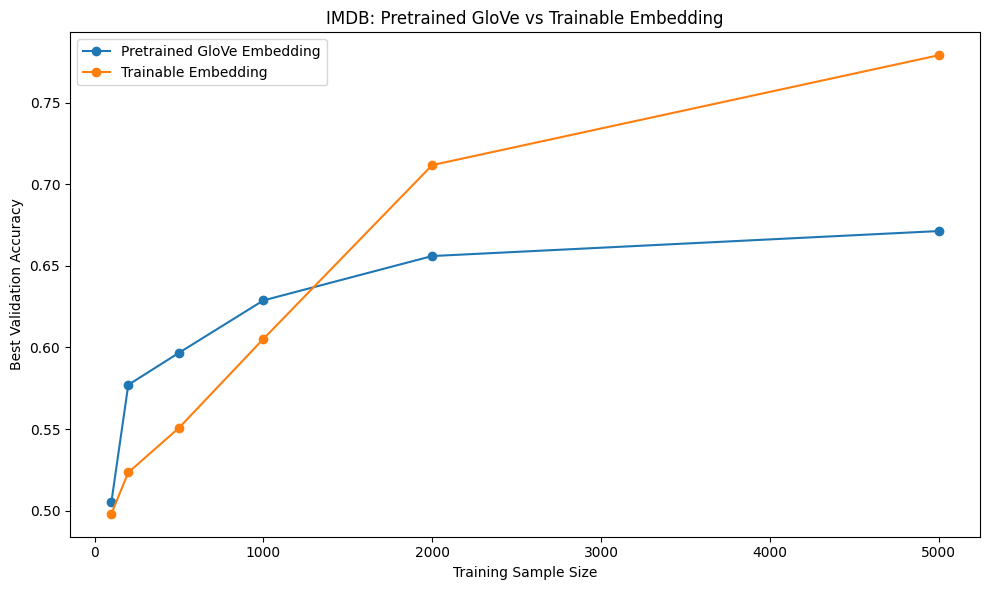

Saved: outputs/results_plot.png


In [13]:
plt.figure(figsize=(10, 6))

for model_name in results_df["model"].unique():
    subset = results_df[results_df["model"] == model_name].sort_values("sample_size")
    plt.plot(
        subset["sample_size"],
        subset["best_val_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training Sample Size")
plt.ylabel("Best Validation Accuracy")
plt.title("IMDB: Pretrained GloVe vs Trainable Embedding")
plt.legend()
plt.tight_layout()

png_path = os.path.join(OUTPUT_DIR, "results_plot.png")
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", png_path)

## Auto-summary

In [14]:
# Determine best run
best_row = results_df.loc[results_df["best_val_accuracy"].idxmax()]

# Find crossover point where trainable first beats pretrained
pivot = results_df.pivot(index="sample_size", columns="model", values="best_val_accuracy")
crossover = None
for size in pivot.index:
    if (
        "Trainable Embedding" in pivot.columns
        and "Pretrained GloVe Embedding" in pivot.columns
        and pivot.loc[size, "Trainable Embedding"] > pivot.loc[size, "Pretrained GloVe Embedding"]
    ):
        crossover = int(size)
        break

summary_text = f'''# Assignment 4 Auto Summary

## Final takeaway
The strongest experiment in this run was **{best_row["model"]}** using **{int(best_row["sample_size"])}** training samples, with a best validation accuracy of **{best_row["best_val_accuracy"]:.4f}**.

## Comparison insight
The trainable embedding first outperformed the pretrained embedding at a training size of {crossover if crossover is not None else "not observed in this run"}.

## What this suggests
- Pretrained embeddings are often stronger when the training set is very small because they bring outside semantic knowledge.
- Trainable embeddings may catch up or exceed pretrained embeddings when more labeled training data becomes available.
- Your final discussion should explain this tradeoff clearly in the report.

## Files generated
- `results.csv`
- `results_plot.png`
'''

summary_path = os.path.join(OUTPUT_DIR, "auto_summary.md")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", summary_path)
print()
print(summary_text)

Saved: outputs/auto_summary.md

# Assignment 4 Auto Summary

## Final takeaway
The strongest experiment in this run was **Trainable Embedding** using **5000** training samples, with a best validation accuracy of **0.7790**.

## Comparison insight
The trainable embedding first outperformed the pretrained embedding at a training size of 2000.

## What this suggests
- Pretrained embeddings are often stronger when the training set is very small because they bring outside semantic knowledge.
- Trainable embeddings may catch up or exceed pretrained embeddings when more labeled training data becomes available.
- Your final discussion should explain this tradeoff clearly in the report.

## Files generated
- `results.csv`
- `results_plot.png`



## Optional: View histories

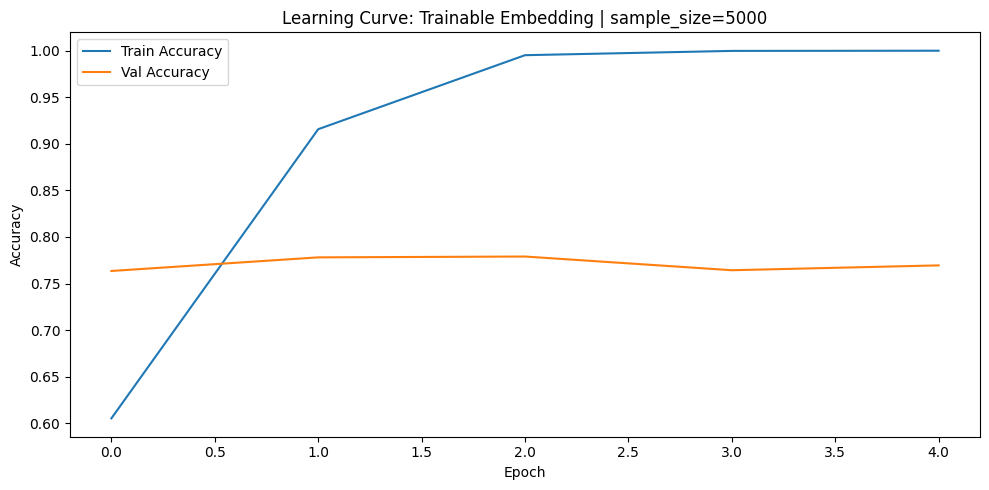

In [15]:
# Example: inspect one run's learning curves
example_key = ("Trainable Embedding", TRAINING_SIZES[-1])

if example_key in histories:
    h = histories[example_key]

    plt.figure(figsize=(10, 5))
    plt.plot(h["accuracy"], label="Train Accuracy")
    plt.plot(h["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Curve: {example_key[0]} | sample_size={example_key[1]}")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No history found for example run.")

## Download files

In [16]:
if IN_COLAB:
    files.download(os.path.join(OUTPUT_DIR, "results.csv"))
    files.download(os.path.join(OUTPUT_DIR, "results_plot.png"))
    files.download(os.path.join(OUTPUT_DIR, "auto_summary.md"))
else:
    print("Download these manually from the outputs folder:")
    print("- outputs/results.csv")
    print("- outputs/results_plot.png")
    print("- outputs/auto_summary.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>